In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from google.colab import drive

# Load Data

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
flight_df = pd.read_csv('/content/drive/MyDrive/Customer Flight Activity.csv')
loyalty_df = pd.read_csv('/content/drive/MyDrive/Customer Loyalty History.csv')

# Data Preprocessing

### **flight_df** (flight data by month)

In [32]:
#Check for missing values
flight_df.isnull().sum()

,0
Loyalty Number,0
Year,0
Month,0
Flights Booked,0
Flights with Companions,0
Total Flights,0
Distance,0
Points Accumulated,0
Points Redeemed,0
Dollar Cost Points Redeemed,0


In [33]:
#Check for duplicates
flight_df.duplicated().sum()

np.int64(1864)

In [34]:
#Drop duplicates
flight_df=flight_df.drop_duplicates()

#Checkfor duplicate entries for the same 'Loyalty Number', 'Year', and 'Month':
duplicate_id_date = flight_df[flight_df.duplicated(subset=['Loyalty Number', 'Year', 'Month'], keep=False)]

if not duplicate_id_date.empty:
    print(f"Found {len(duplicate_id_date)} duplicate entries for the same Loyalty Number and date.")
    display(duplicate_id_date.sort_values(by=['Loyalty Number', 'Year', 'Month']))
else:
    print("No duplicate entries found for the same Loyalty Number and date.")

Found 4138 duplicate entries for the same Loyalty Number and date.


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
50744,101902,2017,4,4,0,4,1460,146.0,0,0
185796,101902,2017,4,4,4,8,2384,238.0,488,40
67645,101902,2017,5,9,3,12,2748,274.0,0,0
67646,101902,2017,5,7,0,7,3318,331.0,0,0
84546,101902,2017,6,10,5,15,3015,301.0,0,0
...,...,...,...,...,...,...,...,...,...,...
371685,992168,2018,10,0,0,0,0,0.0,0,0
130846,992168,2018,11,11,5,16,3360,336.0,502,41
336313,992168,2018,11,1,1,2,546,54.0,343,28
405486,992168,2018,12,15,0,15,3120,312.0,0,0


In [35]:
#Order the duplicate entries by largest Total Flights
flight_df = flight_df.sort_values(['Loyalty Number', 'Year', 'Month', 'Total Flights'],
                    ascending=[True, True, True, False])
flight_df

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
16901,100018,2017,2,2,2,4,1320,132.0,0,0
213311,100018,2017,3,14,3,17,2533,253.0,438,36
50703,100018,2017,4,4,0,4,924,92.0,0,0
67604,100018,2017,5,0,0,0,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...
140741,999986,2018,8,8,1,9,3672,367.0,655,53
354920,999986,2018,9,0,0,0,0,0.0,0,0
371821,999986,2018,10,6,0,6,708,70.0,0,0
388722,999986,2018,11,11,4,15,2040,204.0,0,0


In [36]:
# Keep the entry with the largest Total Flights
flight_df = flight_df.drop_duplicates(subset=['Loyalty Number', 'Year', 'Month'], keep='first')
flight_df = flight_df.reset_index(drop=True)
flight_df

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100018,2017,2,2,2,4,1320,132.0,0,0
2,100018,2017,3,14,3,17,2533,253.0,438,36
3,100018,2017,4,4,0,4,924,92.0,0,0
4,100018,2017,5,0,0,0,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...
401683,999986,2018,8,8,1,9,3672,367.0,655,53
401684,999986,2018,9,0,0,0,0,0.0,0,0
401685,999986,2018,10,6,0,6,708,70.0,0,0
401686,999986,2018,11,11,4,15,2040,204.0,0,0


In [37]:
#Covnvert the Year and Month datatype
flight_df['year_month'] = flight_df['Year'].astype(str) + flight_df['Month'].astype(str).str.zfill(2)

### **loyalty_df** (Member profiles)

In [38]:
#Check for missing values
display(loyalty_df.isnull().sum())

,0
Loyalty Number,0
Country,0
Province,0
City,0
Postal Code,0
Gender,0
Education,0
Salary,4238
Marital Status,0
Loyalty Card,0


In [39]:
#Check for duplicates
loyalty_df.duplicated().sum()

np.int64(0)

In [40]:
#Check for negative values
numeric_df = loyalty_df.select_dtypes(include=np.number)
neg_cols = numeric_df.columns[(numeric_df < 0).any()].tolist()

print(f"Columns with negative values: {neg_cols}")

Columns with negative values: ['Salary']


In [41]:
#Drop unused columns and convert Salary
loyalty_df=loyalty_df.drop(['Postal Code','Country','Province','City',], axis=1)
loyalty_df['Salary'] = loyalty_df['Salary'].abs() # Make negative salary values positive
loyalty_df.reset_index(drop=True, inplace=True)
loyalty_df

,Loyalty Number,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,NaN,NaN
16733,680886,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,NaN,NaN
16734,776187,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,NaN,NaN
16735,906428,Male,Bachelor,57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN


### **flight_summary** (Total Flights and Total Points)

In [42]:
aggregation_columns = ['Total Flights',
    'Flights Booked',
    'Flights with Companions',
    'Distance',
    'Points Accumulated',
    'Points Redeemed',
    'Dollar Cost Points Redeemed'
]

#Dictionary to sum all columns
agg_dict = {col: 'sum' for col in aggregation_columns}

flights_summary = (
    flight_df
    .groupby('Loyalty Number')
    .agg(agg_dict)
    .reset_index()
)

flights_summary.columns = ['Loyalty Number'] + [f'Total_{col.replace(" ", "_")}' for col in aggregation_columns]
flights_summary['Avg_Distance_Per_Flight'] = (
    flights_summary['Total_Distance'] / flights_summary['Total_Total_Flights'].replace(0, np.nan)
).fillna(0)

flights_summary.head()

,Loyalty Number,Total_Total_Flights,Total_Flights_Booked,Total_Flights_with_Companions,Total_Distance,Total_Points_Accumulated,Total_Points_Redeemed,Total_Dollar_Cost_Points_Redeemed,Avg_Distance_Per_Flight
0,100018,192,157,35,50682,5376.00,1513,123,263.968750
1,100102,215,173,42,40222,4115.25,1195,96,187.079070
2,100140,190,152,38,41252,4184.25,593,48,217.115789
3,100214,96,79,17,33982,3426.00,861,70,353.979167
4,100272,163,127,36,40872,4108.04,1007,82,250.748466


### **final** Final DF (contains every member's background, total flights, total points, redeem rate and average flight distance)

In [43]:
final = pd.merge(loyalty_df, flights_summary, on='Loyalty Number', how='inner')
final['Churn'] = np.where(final['Cancellation Month'].isna(), 0, 1) #Add Churn column
final['Point Usage Percentage'] = (final['Total_Points_Redeemed'] / final['Total_Points_Accumulated'])*100
final['Point Usage Percentage'] = final['Point Usage Percentage'].fillna(0)
final

,Loyalty Number,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,...,Total_Total_Flights,Total_Flights_Booked,Total_Flights_with_Companions,Total_Distance,Total_Points_Accumulated,Total_Points_Redeemed,Total_Dollar_Cost_Points_Redeemed,Avg_Distance_Per_Flight,Churn,Point Usage Percentage
0,480934,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,...,171,132,39,51877,5224.44,1418,115,303.374269,0,27.141665
1,549612,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,...,215,190,25,41578,4176.04,1971,159,193.386047,0,47.197824
2,429460,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,...,87,66,21,19664,1963.00,374,30,226.022989,1,19.052471
3,608370,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,...,159,123,36,36043,3626.68,1291,105,226.685535,0,35.597296
4,530508,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,...,176,132,44,36840,3689.68,0,0,209.318182,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,...,139,126,13,40743,4070.00,0,0,293.115108,0,0.000000
16733,680886,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,...,243,198,45,43420,4348.76,1645,132,178.683128,0,37.826875
16734,776187,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,...,207,174,33,49113,4925.56,1529,124,237.260870,0,31.042156
16735,906428,Male,Bachelor,57297.0,Married,Star,10018.66,2018 Promotion,2018,4,...,154,128,26,41381,4166.44,0,0,268.707792,0,0.000000


In [44]:
#Members with 0 flights booked
final[final['Total_Flights_Booked']==0]

,Loyalty Number,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,...,Total_Total_Flights,Total_Flights_Booked,Total_Flights_with_Companions,Total_Distance,Total_Points_Accumulated,Total_Points_Redeemed,Total_Dollar_Cost_Points_Redeemed,Avg_Distance_Per_Flight,Churn,Point Usage Percentage
31,201574,Female,Bachelor,51375.0,Married,Star,3893.31,Standard,2015,4,...,0,0,0,0,0.0,0,0,0.0,1,0.0
39,834891,Female,Bachelor,54460.0,Married,Star,3911.12,Standard,2017,3,...,0,0,0,0,0.0,0,0,0.0,1,0.0
67,329382,Male,College,NaN,Single,Star,3961.59,Standard,2012,8,...,0,0,0,0,0.0,0,0,0.0,0,0.0
72,357549,Female,Bachelor,76410.0,Single,Star,3964.73,Standard,2018,9,...,0,0,0,0,0.0,0,0,0.0,0,0.0
83,283314,Female,Bachelor,72127.0,Married,Star,3991.73,Standard,2013,4,...,0,0,0,0,0.0,0,0,0.0,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16671,959179,Male,Bachelor,56193.0,Divorced,Star,33473.35,Standard,2013,12,...,0,0,0,0,0.0,0,0,0.0,1,0.0
16708,851979,Male,College,NaN,Married,Star,39033.08,Standard,2012,11,...,0,0,0,0,0.0,0,0,0.0,0,0.0
16718,795743,Male,College,NaN,Married,Star,43019.01,Standard,2013,11,...,0,0,0,0,0.0,0,0,0.0,1,0.0
16730,672917,Female,Bachelor,76778.0,Single,Star,58166.55,Standard,2015,1,...,0,0,0,0,0.0,0,0,0.0,1,0.0


In [69]:
# Start date column in YYYYMM
final['start_yyyymm'] = (
    final['Enrollment Year'].astype(int).astype(str) +
    final['Enrollment Month'].astype(int).astype(str).str.zfill(2)
)

# End date column in YYYYMM, fill current members with 201812
final['end_yyyymm'] = (
    final['Cancellation Year'].fillna(0).astype(int).astype(str).str.zfill(4) +
    final['Cancellation Month'].fillna(0).astype(int).astype(str).str.zfill(2)
)

final.loc[final['end_yyyymm'] == '000000', 'end_yyyymm'] = np.nan

final.head()

,Loyalty Number,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,...,Avg_Distance_Per_Flight,Churn,Point Usage Percentage,exchange_rate_group,f.score,last_booking_yyyymm,last_booking_yyyymm_numeric,r.score,start_yyyymm,end_yyyymm
0,480934,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,...,303.374269,0,27.141665,25-30,6,201812,201812.0,8,201602,NaN
1,549612,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,...,193.386047,0,47.197824,45-50,8,201812,201812.0,8,201603,NaN
2,429460,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,...,226.022989,1,19.052471,15-20,3,201801,201801.0,5,201407,201801
3,608370,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,...,226.685535,0,35.597296,35-40,5,201812,201812.0,8,201302,NaN
4,530508,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,...,209.318182,0,0.000000,0-5,6,201812,201812.0,8,201410,NaN


In [93]:
#Calculate member lifecycle in months
def calculate_lifecycle_months(row):
    """Calculate member lifecycle in months"""
    start_year = int(row['start_yyyymm'][:4])
    start_month = int(row['start_yyyymm'][4:])

    # If not yet cancelled, use 2018/12 as end date
    if pd.isna(row['end_yyyymm']):
        end_year = 2018
        end_month = 12
    else:
        end_year = int(row['end_yyyymm'][:4])
        end_month = int(row['end_yyyymm'][4:])

    months = (end_year - start_year) * 12 + (end_month - start_month)
    return months

final['lifecycle_months'] = final.apply(calculate_lifecycle_months, axis=1)

#Filter members with lifecycle <= 12 months
short_lifecycle = final[final['lifecycle_months'] <= 12].copy()

print(f"Total members: {len(final)}")
print(f"Members with lifecycle <= 1 year: {len(short_lifecycle)}")
print(f"Percentage: {len(short_lifecycle)/len(final)*100:.2f}%\n")

Total members: 16737
Members with lifecycle <= 1 year: 4384
Percentage: 26.19%



In [94]:
#Create point usage percentage groups
def categorize_exchange_rate(rate):
    """Categorize exchange rate into groups"""
    if pd.isna(rate):
        return 'Missing'
    elif rate <= 5:
        return '0-5'
    elif rate <= 10:
        return '5-10'
    elif rate <= 15:
        return '10-15'
    elif rate <= 20:
        return '15-20'
    elif rate <= 25:
        return '20-25'
    elif rate <= 30:
        return '25-30'
    elif rate <= 35:
        return '30-35'
    elif rate <= 40:
        return '35-40'
    elif rate <= 45:
        return '40-45'
    elif rate <= 50:
        return '45-50'
    elif rate <= 55:
        return '55-60'
    elif rate <= 60:
        return '60-65'
    elif rate <= 65:
        return '65-70'
    elif rate <= 70:
        return '70-75'
    elif rate <= 75:
        return '75-80'
    elif rate <= 80:
        return '80-85'
    elif rate <= 85:
        return '85-90'
    elif rate <= 90:
        return '90-95'
    elif rate <= 95:
        return '95-100'
    else:
        return '>100'

# Categorize Point Usage Percentage column
final['exchange_rate_group'] = final['Point Usage Percentage'].apply(categorize_exchange_rate)

### **current_members**

In [45]:
current_members=final[final['Cancellation Year'].isna()]

### **cancelled_people** (all members that churned)

In [101]:
cancelled_people = final[final['Cancellation Year'].notna()]
cancelled_people

,Loyalty Number,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,...,Churn,Point Usage Percentage,exchange_rate_group,f.score,last_booking_yyyymm,last_booking_yyyymm_numeric,r.score,start_yyyymm,end_yyyymm,lifecycle_months
2,429460,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,...,1,19.052471,15-20,3,201801,201801.0,5,201407,201801,42
19,354730,Female,College,NaN,Married,Star,3885.46,Standard,2014,10,...,1,0.000000,0-5,3,201801,201801.0,5,201410,201801,39
31,201574,Female,Bachelor,51375.0,Married,Star,3893.31,Standard,2015,4,...,1,0.000000,0-5,0,NaN,NaN,0,201504,201512,8
39,834891,Female,Bachelor,54460.0,Married,Star,3911.12,Standard,2017,3,...,1,0.000000,0-5,0,NaN,NaN,0,201703,201704,1
45,733338,Female,Bachelor,80697.0,Married,Star,3919.37,Standard,2016,6,...,1,0.000000,0-5,1,201701,201701.0,1,201606,201702,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16706,409984,Male,College,NaN,Single,Star,7452.23,2018 Promotion,2018,4,...,1,0.000000,0-5,2,201812,201812.0,8,201804,201812,8
16713,969719,Male,Bachelor,88356.0,Married,Star,40235.97,Standard,2016,5,...,1,520.388350,>100,1,201701,201701.0,1,201605,201701,8
16718,795743,Male,College,NaN,Married,Star,43019.01,Standard,2013,11,...,1,0.000000,0-5,0,NaN,NaN,0,201311,201407,8
16730,672917,Female,Bachelor,76778.0,Single,Star,58166.55,Standard,2015,1,...,1,0.000000,0-5,0,NaN,NaN,0,201501,201509,8


### **cancelled_20172018** (members cancelled in 2017 or 2018)

In [47]:
df = flight_df.merge(
    cancelled_people[['Loyalty Number', 'Cancellation Year', 'Cancellation Month']],
    on='Loyalty Number',
    how='left'
)

# Filter for cancelled customers in 2017 or 2018
cancelled_20172018 = df[(df['Cancellation Year']==2017) | (df['Cancellation Year']==2018)].copy()

cancelled_20172018['YearMonth'] = cancelled_20172018['Year'].astype(str).str.zfill(2) + cancelled_20172018['Month'].astype(str).str.zfill(2)
cancelled_20172018['YearMonth'] = cancelled_20172018['YearMonth'].astype(int)

# Fill NaN with 0 and convert
cancelled_20172018['CancellationYearMonth'] = cancelled_20172018['Cancellation Year'].fillna(0).astype(int).astype(str).str.zfill(2) + cancelled_20172018['Cancellation Month'].fillna(0).astype(int).astype(str).str.zfill(2)
cancelled_20172018['CancellationYearMonth'] = cancelled_20172018['CancellationYearMonth'].astype(int)
cancelled_20172018

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,year_month,Cancellation Year,Cancellation Month,YearMonth,CancellationYearMonth
216,100504,2017,1,0,0,0,0,0.0,0,0,201701,2018.0,3.0,201701,201803
217,100504,2017,2,0,0,0,0,0.0,0,0,201702,2018.0,3.0,201702,201803
218,100504,2017,3,0,0,0,0,0.0,0,0,201703,2018.0,3.0,201703,201803
219,100504,2017,4,0,0,0,0,0.0,0,0,201704,2018.0,3.0,201704,201803
220,100504,2017,5,0,0,0,0,0.0,0,0,201705,2018.0,3.0,201705,201803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401563,999891,2018,8,0,0,0,0,0.0,0,0,201808,2017.0,1.0,201808,201701
401564,999891,2018,9,0,0,0,0,0.0,0,0,201809,2017.0,1.0,201809,201701
401565,999891,2018,10,0,0,0,0,0.0,0,0,201810,2017.0,1.0,201810,201701
401566,999891,2018,11,0,0,0,0,0.0,0,0,201811,2017.0,1.0,201811,201701


#EDA

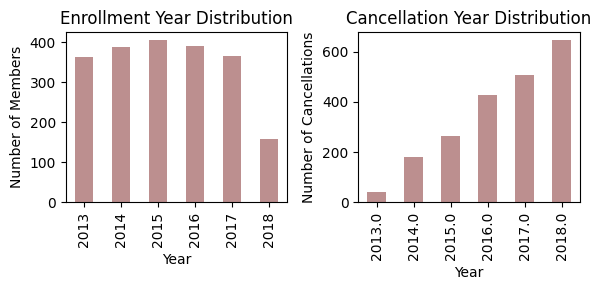

In [48]:
#Explore enrollment and cancellation distribution
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# Enrollment year distribution
cancelled_people["Enrollment Year"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color='rosybrown')
axes[0].set_title("Enrollment Year Distribution")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Members")

# Cancellation year distribution
cancelled_people["Cancellation Year"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color='rosybrown')
axes[1].set_title("Cancellation Year Distribution")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Cancellations")

plt.tight_layout()
plt.show()

In [49]:
#Churn rate and Active Member Count

total_churn = []
active_members_over_time = []
previous_churned = 0  # cumulative churned members

years = sorted(set(final['Enrollment Year']).union(final['Cancellation Year'].dropna().astype(int)))
for year in years:
    # Total members enrolled up to this year
    enrolled_up_to_year = len(final[final['Enrollment Year'] <= year])

    # Subtract previously churned members
    active_members_start_year = enrolled_up_to_year - previous_churned

    # Members who churned this year
    churned_this_year = len(final[final['Cancellation Year'] == year])

    # Update cumulative churned
    previous_churned += churned_this_year

    # Calculate churn rate
    churn_rate = (churned_this_year / active_members_start_year * 100) if active_members_start_year > 0 else 0

    total_churn.append({'Year': year, 'Total Churn Rate (%)': churn_rate})
    active_members_over_time.append({'Year': year, 'Active Members': active_members_start_year})

# Convert to DataFrame
total_churn_df = pd.DataFrame(total_churn)
active_members_df = pd.DataFrame(active_members_over_time)

print("Annual Churn Rate:")
print(total_churn_df)
print("\nActive Member Count Over Time:")
print(active_members_df)

Annual Churn Rate:
   Year  Total Churn Rate (%)
0  2012              0.000000
1  2013              1.053147
2  2014              2.823713
3  2015              3.095794
4  2016              3.971724
5  2017              3.949731
6  2018              4.211557

Active Member Count Over Time:
   Year  Active Members
0  2012            1686
1  2013            4083
2  2014            6410
3  2015            8560
4  2016           10751
5  2017           12811
6  2018           15315


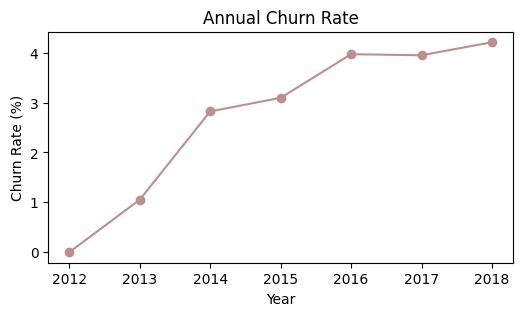

In [50]:
# Plot Annual Churn Rate
plt.figure(figsize=(6,3))
plt.plot(total_churn_df['Year'], total_churn_df['Total Churn Rate (%)'], marker='o', linestyle='-', color='rosybrown')
plt.title('Annual Churn Rate')
plt.xlabel('Year')
plt.ylabel('Churn Rate (%)')
plt.xticks(total_churn_df['Year'])
plt.show()

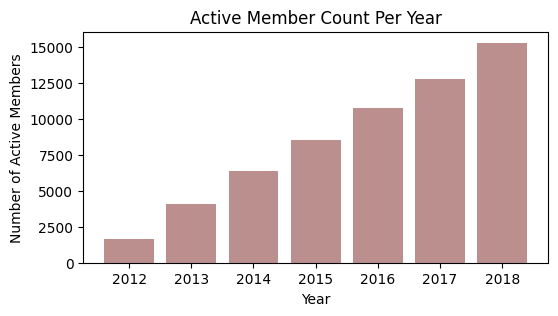

In [51]:
# Plot Active Member Count Over Time
plt.figure(figsize=(6,3))
plt.bar(active_members_df['Year'], active_members_df['Active Members'], color='rosybrown')
plt.title('Active Member Count Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Active Members')
plt.xticks(active_members_df['Year'])  # show every year
plt.show()

In [83]:
#Churn Rate by Loyalty Card
years = sorted(set(final['Enrollment Year']).union(final['Cancellation Year'].dropna().astype(int)))
churn_records = []

for year in years:
    for card, group in final.groupby('Loyalty Card'):
        started = len(group[group['Enrollment Year'] <= year])
        churned = len(group[group['Cancellation Year'] == year])
        churn_rate = (churned / started * 100) if started > 0 else 0
        churn_records.append({'Year': year, 'Loyalty Card': card, 'Churn Rate (%)': churn_rate})

churn_df = pd.DataFrame(churn_records)
churn_df

,Year,Loyalty Card,Churn Rate (%)
0,2012,Aurora,0.000000
1,2012,Nova,0.000000
2,2012,Star,0.000000
3,2013,Aurora,1.075269
4,2013,Nova,0.874636
5,2013,Star,1.173959
6,2014,Aurora,3.293413
7,2014,Nova,2.758621
8,2014,Star,2.617267
9,2015,Aurora,3.058954


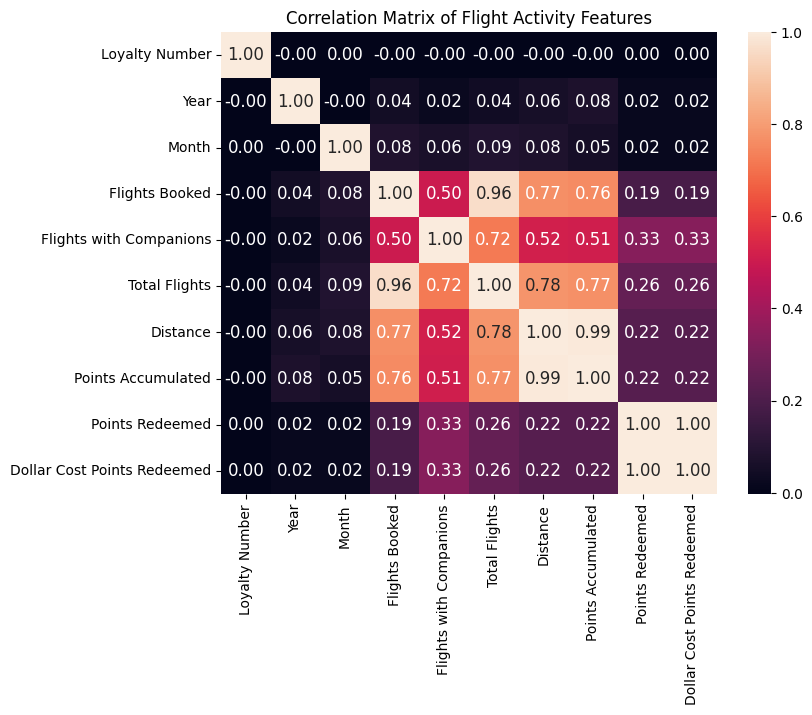

In [170]:
#Flight activity correlation map
numerical_columns = flight_df.select_dtypes(include=np.number)
flight_correlation_matrix = numerical_columns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(flight_correlation_matrix, annot=True, fmt=".2f", cmap='rocket', annot_kws={'fontsize':12}) # Increased font size
plt.title('Correlation Matrix of Flight Activity Features')
plt.show()

In [95]:
#Calculate percentage of members with lifecycle<=1 year in each group
group_analysis = final.groupby('exchange_rate_group').agg({
    'lifecycle_months': [
        ('total_count', 'count'),
        ('short_lifecycle_count', lambda x: (x <= 12).sum())
    ]
}).reset_index()

group_analysis.columns = ['exchange_rate_group', 'total_count', 'short_lifecycle_count']
group_analysis['short_lifecycle_ratio'] = (
    group_analysis['short_lifecycle_count'] / group_analysis['total_count'] * 100
)
group_analysis['long_lifecycle_pct'] = 100 - group_analysis['short_lifecycle_ratio']

# Sort groups
group_order = ['0-5', '5-10', '10-15', '15-20', '20-25', '25-30',
               '30-35', '35-40', '40-45', '45-50', '50-55', '55-60',
               '60-65', '65-70', '70-75', '75-80', '80-85', '85-90',
               '90-95', '95-100', '>100', 'Missing']
group_analysis['sort_key'] = group_analysis['exchange_rate_group'].apply(
    lambda x: group_order.index(x) if x in group_order else 999
)
group_analysis = group_analysis.sort_values('sort_key').drop('sort_key', axis=1)

print("Percentage of members with lifecycle<=1 year by exchange rate group:")
print(group_analysis)

Percentage of members with lifecycle<=1 year by exchange rate group:
   exchange_rate_group  total_count  short_lifecycle_count  \
0                  0-5         5187                   2782   
9                 5-10          611                     30   
1                10-15         1611                     79   
2                15-20         1307                     94   
3                20-25         1393                    123   
4                25-30         1365                    176   
5                30-35         1133                    154   
6                35-40          951                    125   
7                40-45          780                    111   
8                45-50          612                    100   
10               55-60          423                     73   
11               60-65          331                     76   
12               65-70          233                     50   
13               70-75          163                     48   
1

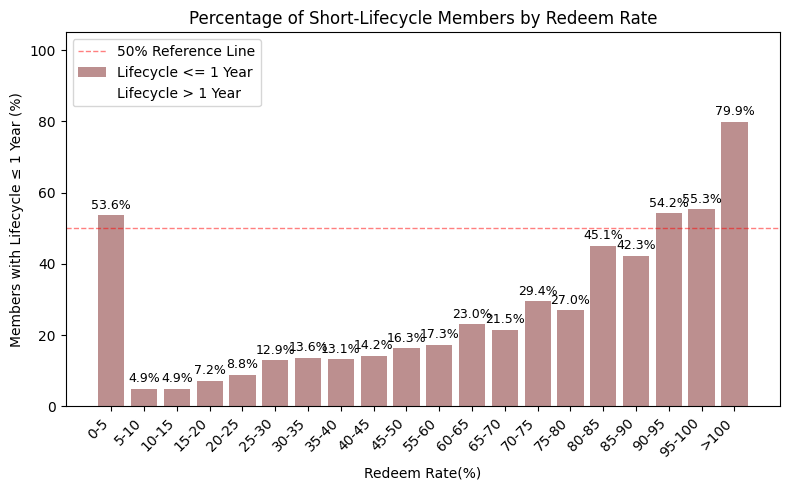

In [96]:
#Visualize percentage of members with lifecycle<=1 year by group
fig1, ax1 = plt.subplots(figsize=(8, 5))

bars_short = ax1.bar(
    range(len(group_analysis)),
    group_analysis['short_lifecycle_ratio'],
    label='Lifecycle <= 1 Year',
    color='rosybrown'
)

bars_long = ax1.bar(
    range(len(group_analysis)),
    group_analysis['long_lifecycle_pct'],
    bottom=group_analysis['short_lifecycle_ratio'],
    label='Lifecycle > 1 Year',
    color = 'white'
)
ax1.set_xlabel('Redeem Rate(%)')
ax1.set_ylabel('Members with Lifecycle ≤ 1 Year (%)')
ax1.set_title('Percentage of Short-Lifecycle Members by Redeem Rate')
ax1.set_xticks(range(len(group_analysis)))
ax1.set_xticklabels(group_analysis['exchange_rate_group'], rotation=45, ha='right')
ax1.axhline(y=50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='50% Reference Line')

for i, ratio in enumerate(group_analysis['short_lifecycle_ratio']):
    ax1.text(i, ratio + 1, f'{ratio:.1f}%',
             ha='center', va='bottom', fontsize=9)

ax1.legend()
plt.tight_layout()
plt.show()

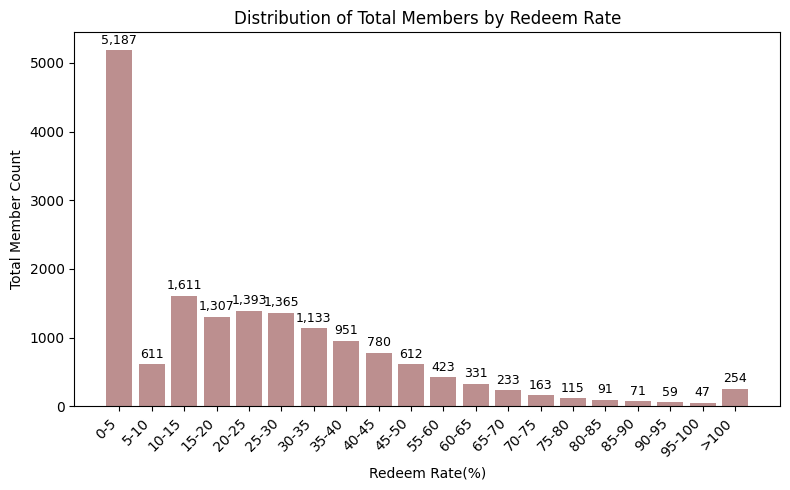

In [98]:
#Visualize number if members in Redeem Rate Groups
fig2, ax2 = plt.subplots(figsize=(8, 5))
bars2 = ax2.bar(range(len(group_analysis)),
                group_analysis['total_count'], color='rosybrown'
                )
ax2.set_xlabel('Redeem Rate(%)')
ax2.set_ylabel('Total Member Count')
ax2.set_title('Distribution of Total Members by Redeem Rate')
ax2.set_xticks(range(len(group_analysis)))
ax2.set_xticklabels(group_analysis['exchange_rate_group'], rotation=45, ha='right')

for i, count in enumerate(group_analysis['total_count']):
    ax2.text(i, count + max(group_analysis['total_count'])*0.01,
             f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [89]:
#High exchange rate groups (>=80%)
high_exchange_groups = ['80-85', '85-90', '90-95', '95-100', '100+']
high_exchange_data = group_analysis[
    group_analysis['exchange_rate_group'].isin(high_exchange_groups)
]

print("High Exchange Rate Group Analysis (≥80%):")
print(high_exchange_data)
print(f"\nTotal members in high exchange rate groups: {high_exchange_data['total_count'].sum():,}")
print(f"Members with lifecycle≤1 year in high exchange rate groups: {high_exchange_data['short_lifecycle_count'].sum():,}")
print(f"Percentage with lifecycle≤1 year in high exchange rate groups: {high_exchange_data['short_lifecycle_count'].sum() / high_exchange_data['total_count'].sum() * 100:.2f}%")

High Exchange Rate Group Analysis (≥80%):
   exchange_rate_group  total_count  short_lifecycle_count  \
15               80-85           91                     41   
16               85-90           71                     30   
17               90-95           59                     32   
18              95-100           47                     26   

    short_lifecycle_ratio  long_lifecycle_pct  
15              45.054945           54.945055  
16              42.253521           57.746479  
17              54.237288           45.762712  
18              55.319149           44.680851  

Total members in high exchange rate groups: 268
Members with lifecycle≤1 year in high exchange rate groups: 129
Percentage with lifecycle≤1 year in high exchange rate groups: 48.13%


In [90]:
#summary_df for Lifecycle Calculation
summary_df = final[final['Cancellation Year'].notna()].groupby('Cancellation Year').agg(
    Total_Cancelled=('Loyalty Number', 'count'),
    Cancelled_Within_1_Year=('lifecycle_months', lambda x: (x <= 12).sum())
).reset_index()

print(summary_df)

   Cancellation Year  Total_Cancelled  Cancelled_Within_1_Year
0             2013.0               43                       43
1             2014.0              181                      154
2             2015.0              265                      193
3             2016.0              427                      285
4             2017.0              506                      312
5             2018.0              645                      382


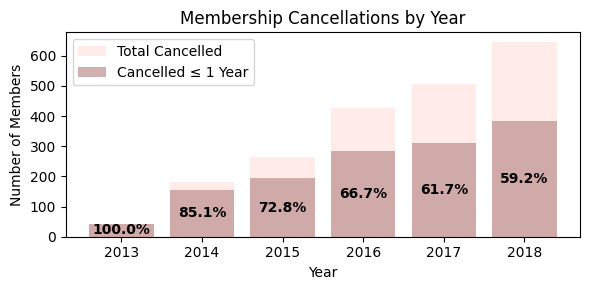

In [99]:
#Visualize
plt.figure(figsize=(6,3))

bars1 = plt.bar(summary_df['Cancellation Year'], summary_df['Total_Cancelled'],
                label='Total Cancelled', alpha=0.7, color='mistyrose')

bars2 = plt.bar(summary_df['Cancellation Year'], summary_df['Cancelled_Within_1_Year'],
                label='Cancelled ≤ 1 Year', alpha=0.7, color='rosybrown')

for bar_total, bar_sub, (_, row) in zip(bars1, bars2, summary_df.iterrows()):
    total = row['Total_Cancelled']
    sub = row['Cancelled_Within_1_Year']
    pct = (sub / total * 100) if total > 0 else 0

    plt.text(
        bar_sub.get_x() + bar_sub.get_width()/2,
        bar_sub.get_height()/2,
        f"{pct:.1f}%",
        ha='center', va='center', color='black', fontsize=10, fontweight='bold'
    )

plt.title('Membership Cancellations by Year')
plt.xlabel('Year')
plt.ylabel('Number of Members')
plt.legend()
plt.tight_layout()
plt.show()

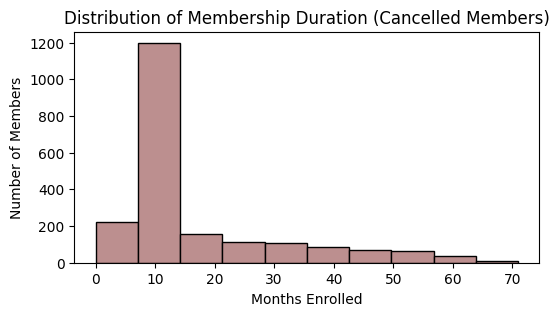

In [102]:
plt.figure(figsize=(6,3))
plt.hist(cancelled_people["lifecycle_months"], bins=10, edgecolor="black", color='rosybrown')
plt.xlabel("Membership Duration (Months)")
plt.title("Distribution of Membership Duration (Cancelled Members)")
plt.xlabel("Months Enrolled")
plt.ylabel("Number of Members")
plt.show()

# RF Score


In [55]:
conditions = [
    final['Total_Flights_Booked'] == 0,
    final['Total_Flights_Booked'] <= 24.9,
    final['Total_Flights_Booked'] <= 49.8,
    final['Total_Flights_Booked'] <= 74.7,
    final['Total_Flights_Booked'] <= 99.6,
    final['Total_Flights_Booked'] <= 124.5,
    final['Total_Flights_Booked'] <= 149,
    final['Total_Flights_Booked'] <= 174,
    final['Total_Flights_Booked'] <= 199.2,
    final['Total_Flights_Booked'] <= 224.1
]

choices = [0,1, 2, 3, 4, 5, 6, 7, 8, 9]

final['f.score'] = np.select(conditions, choices, default=10)

display(final[['Loyalty Number', 'Total_Flights_Booked', 'f.score']].head())

,Loyalty Number,Total_Flights_Booked,f.score
0,480934,132,6
1,549612,190,8
2,429460,66,3
3,608370,123,5
4,530508,132,6


In [56]:
conditions = (flight_df['year_month'] == '201812') & (flight_df['Flights Booked'] != 0)

flight_df['last_book'] = np.where(conditions, flight_df['year_month'], np.nan)

display(flight_df.dropna(subset=['last_book']).head(100))

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,year_month,last_book
23,100018,2018,12,17,6,23,4945,494.0,0,0,201812,201812
47,100102,2018,12,14,0,14,2436,243.0,0,0,201812,201812
95,100214,2018,12,10,0,10,3590,359.0,0,0,201812,201812
143,100301,2018,12,11,5,16,1184,118.0,0,0,201812,201812
167,100364,2018,12,6,3,9,2475,247.0,0,0,201812,201812
...,...,...,...,...,...,...,...,...,...,...,...,...
3575,107461,2018,12,13,2,15,3120,312.0,0,0,201812,201812
3599,107466,2018,12,5,0,5,3505,350.0,0,0,201812,201812
3623,107487,2018,12,12,8,20,2880,288.0,0,0,201812,201812
3671,107571,2018,12,9,8,17,4454,445.0,0,0,201812,201812


In [57]:
bookings_only = flight_df[flight_df['Flights Booked'] > 0].copy()


last_booking_date = bookings_only.groupby('Loyalty Number')['year_month'].max().reset_index()
last_booking_date.rename(columns={'year_month': 'last_booking_yyyymm'}, inplace=True)

final = final.drop(columns=['last_booking_yyyymm_x', 'last_booking_yyyymm_y'], errors='ignore')
final = pd.merge(final, last_booking_date, on='Loyalty Number', how='left')

final['last_booking_yyyymm_numeric'] = pd.to_numeric(final['last_booking_yyyymm'], errors='coerce')

display(final.head())

,Loyalty Number,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,...,Total_Points_Accumulated,Total_Points_Redeemed,Total_Dollar_Cost_Points_Redeemed,Avg_Distance_Per_Flight,Churn,Point Usage Percentage,exchange_rate_group,f.score,last_booking_yyyymm,last_booking_yyyymm_numeric
0,480934,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,...,5224.44,1418,115,303.374269,0,27.141665,25-30,6,201812,201812.0
1,549612,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,...,4176.04,1971,159,193.386047,0,47.197824,45-50,8,201812,201812.0
2,429460,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,...,1963.00,374,30,226.022989,1,19.052471,15-20,3,201801,201801.0
3,608370,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,...,3626.68,1291,105,226.685535,0,35.597296,35-40,5,201812,201812.0
4,530508,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,...,3689.68,0,0,209.318182,0,0.000000,0-5,6,201812,201812.0


In [58]:
conditions = [
    (final['last_booking_yyyymm_numeric'] >= 201810) & (final['last_booking_yyyymm_numeric'] <= 201812),
    (final['last_booking_yyyymm_numeric'] >= 201807) & (final['last_booking_yyyymm_numeric'] <= 201809),
    (final['last_booking_yyyymm_numeric'] >= 201804) & (final['last_booking_yyyymm_numeric'] <= 201806),
    (final['last_booking_yyyymm_numeric'] >= 201801) & (final['last_booking_yyyymm_numeric'] <= 201803),
    (final['last_booking_yyyymm_numeric'] >= 201710) & (final['last_booking_yyyymm_numeric'] <= 201712),
    (final['last_booking_yyyymm_numeric'] >= 201707) & (final['last_booking_yyyymm_numeric'] <= 201709),
    (final['last_booking_yyyymm_numeric'] >= 201704) & (final['last_booking_yyyymm_numeric'] <= 201706),
    (final['last_booking_yyyymm_numeric'] >= 201701) & (final['last_booking_yyyymm_numeric'] <= 201703)
]


choices = [8, 7, 6, 5, 4, 3, 2,1]

final['r.score'] = np.select(conditions, choices, default=0)

display(final[['Loyalty Number', 'last_booking_yyyymm', 'last_booking_yyyymm_numeric', 'r.score']].head())

,Loyalty Number,last_booking_yyyymm,last_booking_yyyymm_numeric,r.score
0,480934,201812,201812.0,8
1,549612,201812,201812.0,8
2,429460,201801,201801.0,5
3,608370,201812,201812.0,8
4,530508,201812,201812.0,8


In [59]:
final

,Loyalty Number,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,...,Total_Points_Redeemed,Total_Dollar_Cost_Points_Redeemed,Avg_Distance_Per_Flight,Churn,Point Usage Percentage,exchange_rate_group,f.score,last_booking_yyyymm,last_booking_yyyymm_numeric,r.score
0,480934,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,...,1418,115,303.374269,0,27.141665,25-30,6,201812,201812.0,8
1,549612,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,...,1971,159,193.386047,0,47.197824,45-50,8,201812,201812.0,8
2,429460,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,...,374,30,226.022989,1,19.052471,15-20,3,201801,201801.0,5
3,608370,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,...,1291,105,226.685535,0,35.597296,35-40,5,201812,201812.0,8
4,530508,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,...,0,0,209.318182,0,0.000000,0-5,6,201812,201812.0,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,...,0,0,293.115108,0,0.000000,0-5,6,201812,201812.0,8
16733,680886,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,...,1645,132,178.683128,0,37.826875,35-40,8,201812,201812.0,8
16734,776187,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,...,1529,124,237.260870,0,31.042156,30-35,7,201812,201812.0,8
16735,906428,Male,Bachelor,57297.0,Married,Star,10018.66,2018 Promotion,2018,4,...,0,0,268.707792,0,0.000000,0-5,6,201812,201812.0,8


In [60]:
from google.colab import drive
drive.mount('/content/drive')
final.to_excel("/content/drive/MyDrive/merged_result.xlsx", index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# KMeans

In [61]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/DA/fr.churn.csv")

In [62]:
df

,Loyalty Number,Churn,f.score,r.score
0,480934,0,6,8
1,549612,0,8,8
2,429460,1,3,5
3,608370,0,5,8
4,530508,0,6,8
...,...,...,...,...
16732,823768,0,6,8
16733,680886,0,8,8
16734,776187,0,7,8
16735,906428,0,6,8


In [63]:
#Keep data where R and F score are positive
df1 = df[(df['f.score'] > 0) & (df['r.score'] > 0)]
df1

,Loyalty Number,Churn,f.score,r.score
0,480934,0,6,8
1,549612,0,8,8
2,429460,1,3,5
3,608370,0,5,8
4,530508,0,6,8
...,...,...,...,...
16731,900501,0,5,8
16732,823768,0,6,8
16733,680886,0,8,8
16734,776187,0,7,8


In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df1[['f.score', 'r.score']])

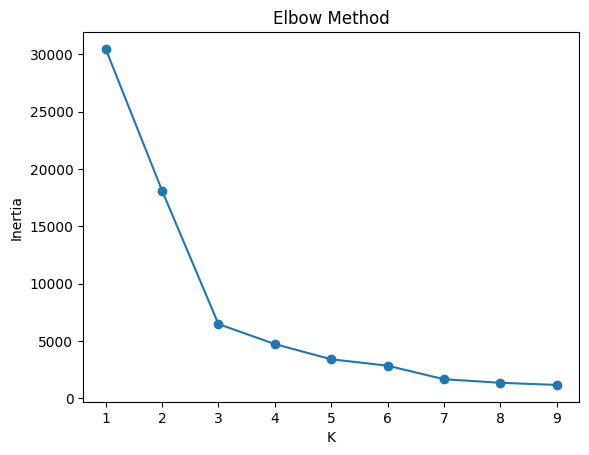

In [65]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


In [150]:
kmeans = KMeans(n_clusters=4, random_state=42)
df1['cluster'] = kmeans.fit_predict(df_scaled)

/tmp/ipykernel_11279/444113718.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['cluster'] = kmeans.fit_predict(df_scaled)


In [151]:
df1.groupby('cluster')[['f.score', 'r.score','Churn']].mean()

,f.score,r.score,Churn
cluster,,,
0,2.815766,7.882760,0.076373
1,5.530545,7.958448,0.014584
2,2.219917,3.100968,0.912863
3,7.249368,7.987351,0.007589


# **Clusters**
*   0 : F medium-high, R high -> medium frequency X recent consumption
*   1 : F extremely low, R extremely low -> extremely low frequency X long time without consumption
*   2 : F high, R highest -> highest frequency X recent consumption (most active)
*   3 : F relatively low, R relatively high -> low frequency

In [152]:
df1.groupby('cluster').size()

,0
cluster,
0,4478
1,7268
2,723
3,2767


In [153]:
# Merge final dataframe with clusters
merged_cluster_data = pd.merge(final, df1[['Loyalty Number', 'cluster']], on='Loyalty Number', how='inner')

# Filter out Point Usage Percentage > 100 AND Avg_Distance_Per_Flight > 500
merged_cluster_data_filtered = merged_cluster_data[
    (merged_cluster_data['Point Usage Percentage'] <= 100) &
    (merged_cluster_data['Avg_Distance_Per_Flight'] <= 500)
].copy()

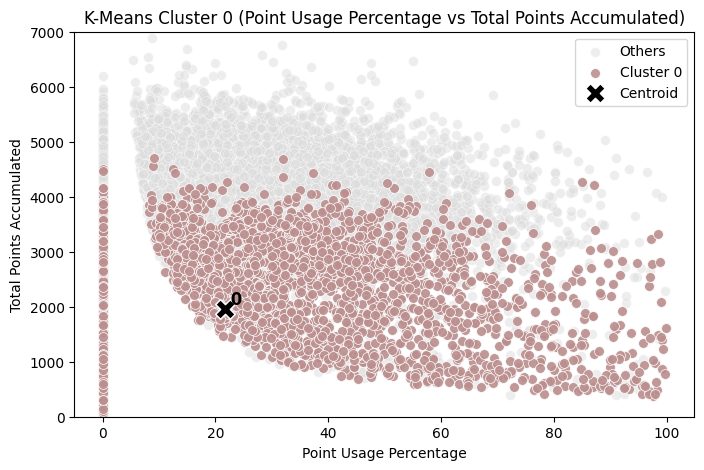

In [154]:
# Filter for cluster 0
merged_cluster_data_filtered_0 = merged_cluster_data_filtered[merged_cluster_data_filtered['cluster'] == 0]

# Calculate centroids
centroids_new_features = merged_cluster_data_filtered_0.groupby('cluster')[['Total_Points_Accumulated', 'Point Usage Percentage']].mean().reset_index()

plt.figure(figsize=(8, 5))

# Plot the entire dataset in the background (zorder=0)
sns.scatterplot(
    x='Point Usage Percentage',
    y='Total_Points_Accumulated',
    data=merged_cluster_data[
        (merged_cluster_data['Point Usage Percentage'] <= 100) &
        (merged_cluster_data['Avg_Distance_Per_Flight'] <= 500)
    ],
    color='gainsboro',
    s=50,
    alpha=0.5,
    label='Others',
    zorder=0
)

# Plot non-churned members (zorder=1)
sns.scatterplot(
    x='Point Usage Percentage',
    y='Total_Points_Accumulated',
    data=merged_cluster_data_filtered_0,
    color='rosybrown',
    s=50,
    alpha=0.9,
    label='Cluster 0',
    zorder=1
)

# Plot centroids (zorder=3)
sns.scatterplot(
    x='Point Usage Percentage',
    y='Total_Points_Accumulated',
    data=centroids_new_features,
    marker='X',
    s=200,
    color='black',
    label='Centroid',
    zorder=3
)

# Annotate centroids with cluster number
for i, row in centroids_new_features.iterrows():
    plt.text(row['Point Usage Percentage'], row['Total_Points_Accumulated'], f' {int(row['cluster'])}',
             horizontalalignment='left', verticalalignment='bottom', fontsize=12, color='black', weight='bold', zorder=4)

plt.title('K-Means Cluster 0 (Point Usage Percentage vs Total Points Accumulated)')
plt.xlabel('Point Usage Percentage')
plt.ylabel('Total Points Accumulated')
plt.legend()
plt.ylim(0, 7000)
plt.show()

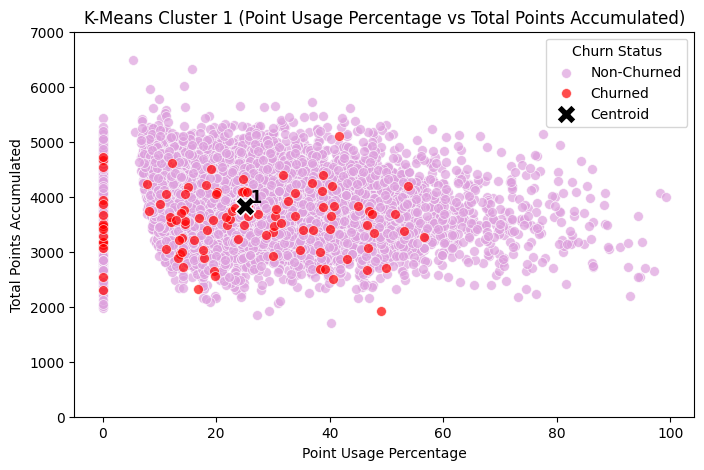

In [155]:
# Filter for cluster 1
merged_cluster_data_filtered_1 = merged_cluster_data_filtered[merged_cluster_data_filtered['cluster'] == 1]

# Calculate centroids for the new features on the filtered data
centroids_new_features = merged_cluster_data_filtered_1.groupby('cluster')[['Total_Points_Accumulated', 'Point Usage Percentage']].mean().reset_index()

plt.figure(figsize=(8, 5))

# Plot non-churned members (zorder=1)
sns.scatterplot(
    x='Point Usage Percentage',
    y='Total_Points_Accumulated',
    data=merged_cluster_data_filtered_1[merged_cluster_data_filtered_1['Churn'] == 0],
    color='plum',
    s=50,
    alpha=0.7,
    label='Non-Churned',
    zorder=1
)

# Plot churned members (zorder=2)
sns.scatterplot(
    x='Point Usage Percentage',
    y='Total_Points_Accumulated',
    data=merged_cluster_data_filtered_1[merged_cluster_data_filtered_1['Churn'] == 1],
    color='red',
    s=50,
    alpha=0.7,
    label='Churned',
    zorder=2
)

# Plot centroids (zorder=3)
sns.scatterplot(
    x='Point Usage Percentage',
    y='Total_Points_Accumulated',
    data=centroids_new_features,
    marker='X',
    s=200,
    color='black',
    label='Centroid',
    zorder=3
)

# Annotate centroids with their cluster number
for i, row in centroids_new_features.iterrows():
    plt.text(row['Point Usage Percentage'], row['Total_Points_Accumulated'], f' {int(row['cluster'])}',
             horizontalalignment='left', verticalalignment='bottom', fontsize=12, color='black', weight='bold', zorder=4)

plt.title('K-Means Cluster 1 (Point Usage Percentage vs Total Points Accumulated)')
plt.xlabel('Point Usage Percentage')
plt.ylabel('Total Points Accumulated')
plt.legend(title='Churn Status')
plt.ylim(0, 7000) # Set y-axis limit
plt.show()

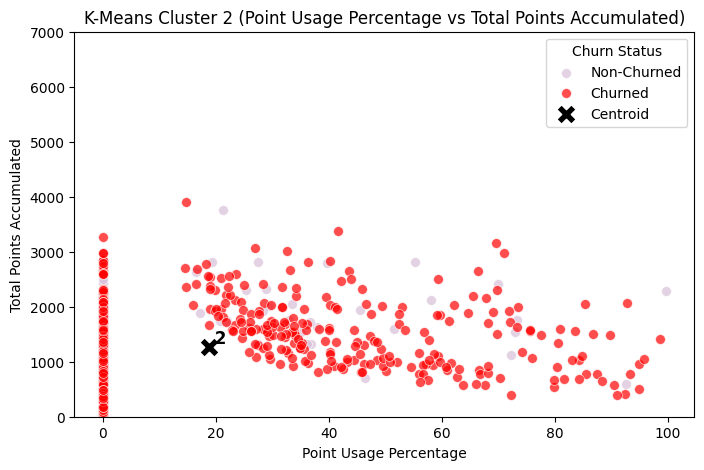

In [156]:
# Filter for cluster 2
merged_cluster_data_filtered_2 = merged_cluster_data_filtered[merged_cluster_data_filtered['cluster'] == 2]

# Calculate centroids
centroids_new_features = merged_cluster_data_filtered_2.groupby('cluster')[['Total_Points_Accumulated', 'Point Usage Percentage']].mean().reset_index()

plt.figure(figsize=(8, 5))

# Plot non-churned members (zorder=1)
sns.scatterplot(
    x='Point Usage Percentage',
    y='Total_Points_Accumulated',
    data=merged_cluster_data_filtered_2[merged_cluster_data_filtered_2['Churn'] == 0],
    color='thistle',
    s=50,
    alpha=0.7,
    label='Non-Churned',
    zorder=1
)

# Plot churned members (zorder=2)
sns.scatterplot(
    x='Point Usage Percentage',
    y='Total_Points_Accumulated',
    data=merged_cluster_data_filtered_2[merged_cluster_data_filtered_2['Churn'] == 1],
    color='red',
    s=50,
    alpha=0.7,
    label='Churned',
    zorder=2
)

# Plot centroids (zorder=3)
sns.scatterplot(
    x='Point Usage Percentage',
    y='Total_Points_Accumulated',
    data=centroids_new_features,
    marker='X',
    s=200,
    color='black',
    label='Centroid',
    zorder=3
)

# Annotate centroids with cluster number
for i, row in centroids_new_features.iterrows():
    plt.text(row['Point Usage Percentage'], row['Total_Points_Accumulated'], f' {int(row['cluster'])}',
             horizontalalignment='left', verticalalignment='bottom', fontsize=12, color='black', weight='bold', zorder=4)

plt.title('K-Means Cluster 2 (Point Usage Percentage vs Total Points Accumulated)')
plt.xlabel('Point Usage Percentage')
plt.ylabel('Total Points Accumulated')
plt.legend(title='Churn Status')
plt.ylim(0, 7000)
plt.show()

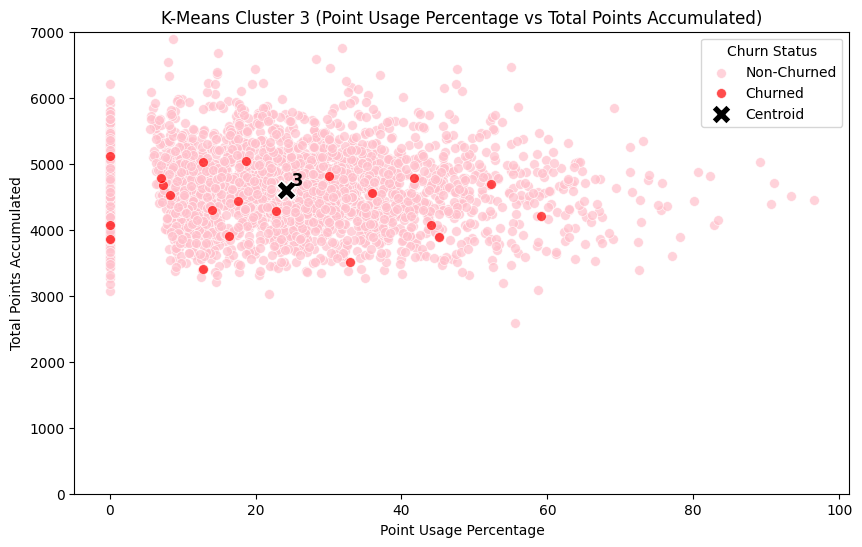

In [157]:
# Filter for cluster 3
merged_cluster_data_filtered_3 = merged_cluster_data_filtered[merged_cluster_data_filtered['cluster'] == 3]

# Calculate centroids for the new features on the filtered data
centroids_new_features = merged_cluster_data_filtered_3.groupby('cluster')[['Total_Points_Accumulated', 'Point Usage Percentage']].mean().reset_index()

plt.figure(figsize=(10, 6))

# Plot non-churned members (zorder=1)
sns.scatterplot(
    x='Point Usage Percentage',
    y='Total_Points_Accumulated',
    data=merged_cluster_data_filtered_3[merged_cluster_data_filtered_3['Churn'] == 0],
    color='pink',
    s=50,
    alpha=0.7,
    label='Non-Churned',
    zorder=1
)

# Plot churned members (zorder=2)
sns.scatterplot(
    x='Point Usage Percentage',
    y='Total_Points_Accumulated',
    data=merged_cluster_data_filtered_3[merged_cluster_data_filtered_3['Churn'] == 1],
    color='red',
    s=50,
    alpha=0.7,
    label='Churned',
    zorder=2
)

# Plot centroids (zorder=3)
sns.scatterplot(
    x='Point Usage Percentage',
    y='Total_Points_Accumulated',
    data=centroids_new_features,
    marker='X',
    s=200,
    color='black',
    label='Centroid',
    zorder=3
)

# Annotate centroids with their cluster number
for i, row in centroids_new_features.iterrows():
    plt.text(row['Point Usage Percentage'], row['Total_Points_Accumulated'], f' {int(row['cluster'])}',
             horizontalalignment='left', verticalalignment='bottom', fontsize=12, color='black', weight='bold', zorder=4)

plt.title('K-Means Cluster 3 (Point Usage Percentage vs Total Points Accumulated)')
plt.xlabel('Point Usage Percentage')
plt.ylabel('Total Points Accumulated')
plt.legend(title='Churn Status')
plt.ylim(0, 7000) # Set y-axis limit
plt.show()

In [159]:
#Average distance distribution between clusters
avg_distance_by_cluster = merged_cluster_data.groupby('cluster')['Avg_Distance_Per_Flight'].mean().reset_index()
display(avg_distance_by_cluster)

,cluster,Avg_Distance_Per_Flight
0,0,260.356761
1,1,239.281851
2,2,257.294891
3,3,219.931825


In [160]:
#Gender distribution among clusters
gender_counts_by_cluster = merged_cluster_data.groupby('cluster')['Gender'].value_counts().unstack(fill_value=0)
display(gender_counts_by_cluster)

Gender,Female,Male
cluster,,
0,2254,2224
1,3642,3626
2,365,358
3,1367,1400


In [162]:
#Loyalty card distribution among clusters
lc_counts_by_cluster = merged_cluster_data.groupby('cluster')['Loyalty Card'].value_counts().unstack(fill_value=0)
display(lc_counts_by_cluster)

Loyalty Card,Aurora,Nova,Star
cluster,,,
0,892,1495,2091
1,1499,2425,3344
2,143,267,313
3,578,964,1225


In [161]:
#Education distribution among clusters
education_counts_by_cluster = merged_cluster_data.groupby('cluster')['Education'].value_counts().unstack(fill_value=0)
display(education_counts_by_cluster)

Education,Bachelor,College,Doctor,High School or Below,Master
cluster,,,,,
0,2834,1137,179,190,138
1,4550,1824,308,365,221
2,433,197,30,36,27
3,1700,730,138,116,83


#Seasonal Bookings

In [164]:
flight_data_with_clusters = pd.merge(flight_df, df1[['Loyalty Number', 'cluster']], on='Loyalty Number', how='inner')
flight_data_with_clusters.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,year_month,last_book,cluster
0,100018,2017,1,3,0,3,1521,152.0,0,0,201701,NaN,3
1,100018,2017,2,2,2,4,1320,132.0,0,0,201702,NaN,3
2,100018,2017,3,14,3,17,2533,253.0,438,36,201703,NaN,3
3,100018,2017,4,4,0,4,924,92.0,0,0,201704,NaN,3
4,100018,2017,5,0,0,0,0,0.0,0,0,201705,NaN,3


In [165]:
filtered_flight_data = flight_data_with_clusters[
    (flight_data_with_clusters['year_month'] >= '201701') &
    (flight_data_with_clusters['year_month'] <= '201812')
].copy()
filtered_flight_data.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,year_month,last_book,cluster
0,100018,2017,1,3,0,3,1521,152.0,0,0,201701,NaN,3
1,100018,2017,2,2,2,4,1320,132.0,0,0,201702,NaN,3
2,100018,2017,3,14,3,17,2533,253.0,438,36,201703,NaN,3
3,100018,2017,4,4,0,4,924,92.0,0,0,201704,NaN,3
4,100018,2017,5,0,0,0,0,0.0,0,0,201705,NaN,3


In [166]:
monthly_bookings_by_cluster = filtered_flight_data.groupby(['year_month', 'cluster'])['Total Flights'].sum().reset_index()
monthly_bookings_by_cluster.head()

,year_month,cluster,Total Flights
0,201701,0,4685
1,201701,1,34754
2,201701,2,3023
3,201701,3,17293
4,201702,0,4751


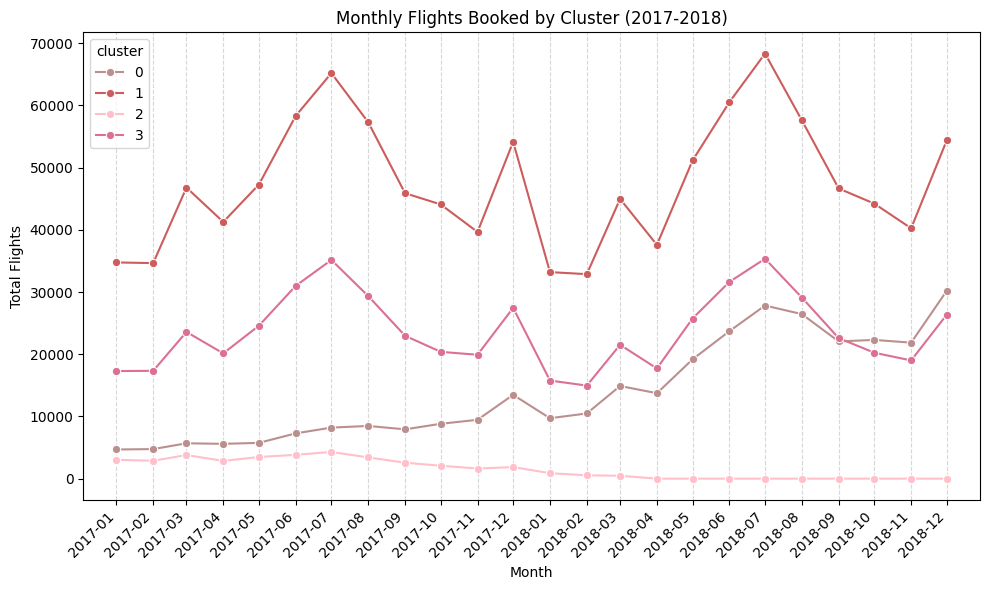

In [167]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. Convert 'year_month' to datetime object
monthly_bookings_by_cluster['year_month'] = pd.to_datetime(monthly_bookings_by_cluster['year_month'], format='%Y%m')

#color palette
cluster_colors = {
    0: 'rosybrown',
    1: 'indianred',
    2: 'pink',
    3: 'palevioletred'
}

plt.figure(figsize=(10, 6))
sns.lineplot(
    x='year_month',
    y='Total Flights',
    hue='cluster',
    data=monthly_bookings_by_cluster,
    marker='o',
    palette=cluster_colors
)
plt.title('Monthly Flights Booked by Cluster (2017-2018)')
plt.xlabel('Month')
plt.ylabel('Total Flights')

# Set labels
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # Format as YYYY-MM


plt.xticks(rotation=45, ha='right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.margins(x=0.04)
plt.show()

# Redeem Rate Analysis

In [103]:
#Churn by Redeem Rate
bins = np.linspace(0, 100, 21)
labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]

final['redeem_bin'] = pd.cut(final['Point Usage Percentage'], bins=bins, labels=labels, include_lowest=True)

new_categories = list(final['redeem_bin'].cat.categories) + ['> 100']
final['redeem_bin'] = final['redeem_bin'].cat.set_categories(new_categories)

final.loc[final['Point Usage Percentage'] > 100, 'redeem_bin'] = '> 100'

churn_by_redeem_bin = (
      final.groupby('redeem_bin')['Cancellation Year']
      .apply(lambda x: x.notna().mean())
      .reset_index(name='churn_rate')
)

bin_counts = (
    final.groupby('redeem_bin')
         .size()
         .reset_index(name='Loyalty Number')
)
print(churn_by_redeem_bin)

churn_by_redeem_bin['churn_rate'] *= 100

# Merge churn rate with total counts
plot_df = churn_by_redeem_bin.merge(bin_counts, on='redeem_bin')
plot_df = plot_df.sort_values(by='redeem_bin')

   redeem_bin  churn_rate
0         0-5    0.288799
1        5-10    0.008183
2       10-15    0.017381
3       15-20    0.031370
4       20-25    0.034458
5       25-30    0.035165
6       30-35    0.057370
7       35-40    0.050473
8       40-45    0.050000
9       45-50    0.070261
10      50-55    0.052009
11      55-60    0.093656
12      60-65    0.068670
13      65-70    0.128834
14      70-75    0.104348
15      75-80    0.131868
16      80-85    0.140845
17      85-90    0.152542
18      90-95    0.255319
19     95-100    0.048780
20      > 100    0.267606


/tmp/ipykernel_11279/636212635.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final.groupby('redeem_bin')['Cancellation Year']
/tmp/ipykernel_11279/636212635.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final.groupby('redeem_bin')


In [104]:
#Average Flight Distance by Redeem Rate
distance_summary = (final.groupby('redeem_bin')['Total_Distance']
         .agg(['sum', 'count'])
         .reset_index()
         .rename(columns={'sum': 'Total_Distance', 'count': 'Member_Count'})
)

# Average Distance
distance_summary['Avg_Distance'] = (
    distance_summary['Total_Distance'] / distance_summary['Member_Count']
)

distance_summary = distance_summary.sort_values(by='redeem_bin')

/tmp/ipykernel_11279/3170947107.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_summary = (final.groupby('redeem_bin')['Total_Distance']


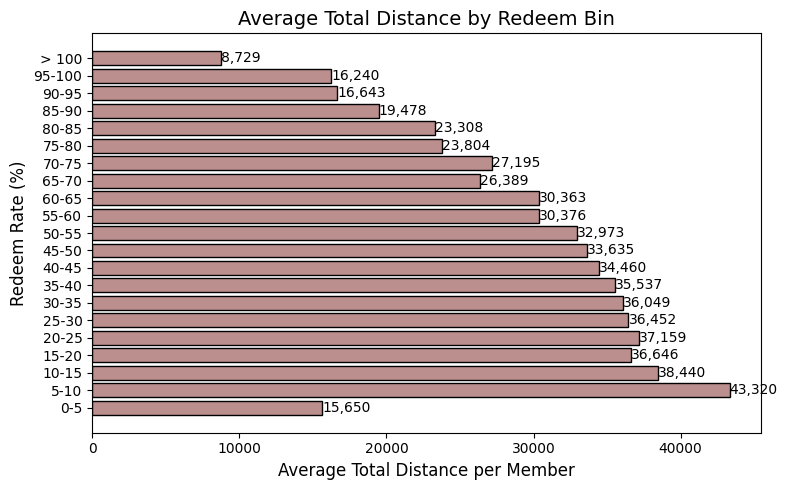

In [105]:
#Visualize
plt.figure(figsize=(8, 5))
plt.barh(distance_summary['redeem_bin'], distance_summary['Avg_Distance'],
         color='rosybrown', edgecolor='black')

plt.title("Average Total Distance by Redeem Bin", fontsize=14)
plt.xlabel("Average Total Distance per Member", fontsize=12)
plt.ylabel("Redeem Rate (%)", fontsize=12)

for index, value in enumerate(distance_summary['Avg_Distance']):
    plt.text(value, index, f'{value:,.0f}', va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_11279/846103882.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(plot_df['redeem_bin'].astype(str), rotation=45, ha='right')


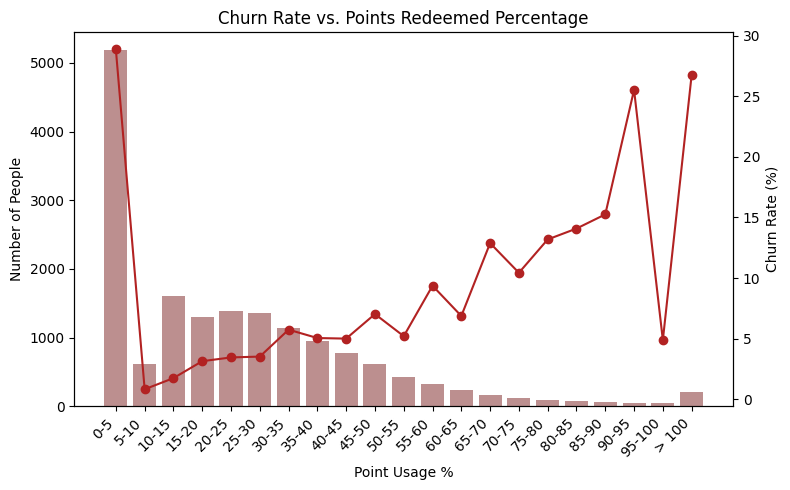

In [106]:
#Member Count and Churn Rate by Redeem Rate
fig, ax1 = plt.subplots(figsize=(8,5))

# Bar chart for total people
ax1.bar(plot_df['redeem_bin'].astype(str), plot_df['Loyalty Number'], color='rosybrown') # Changed color to lightcoral
ax1.set_xticklabels(plot_df['redeem_bin'].astype(str), rotation=45, ha='right')
ax1.set_ylabel('Number of People')
ax1.set_xlabel('Point Usage %')

# churn rate (line chart)
ax2 = ax1.twinx()
ax2.plot(plot_df['redeem_bin'].astype(str), plot_df['churn_rate'], marker='o', color='firebrick') # Changed color to firebrick
ax2.set_ylabel('Churn Rate (%)')

plt.title('Churn Rate vs. Points Redeemed Percentage')
plt.tight_layout()
plt.show()

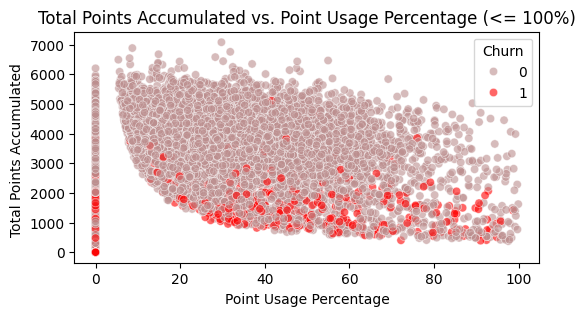

In [126]:
# Filter out members with point usage percentage over 100%
final_usage_filtered = final[final['Point Usage Percentage'] <= 100].copy()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=final_usage_filtered, x='Point Usage Percentage', y='Total_Points_Accumulated', hue='Churn', alpha=0.6,palette=['rosybrown', 'red'])

plt.title('Total Points Accumulated vs. Point Usage Percentage (<= 100%)')
plt.xlabel('Point Usage Percentage')
plt.ylabel('Total Points Accumulated ')
plt.show()

# Member Activity

In [107]:
#Explore whether members are active within 3 months of cancellation
cancelled_20172018['months_before_cancellation'] = (cancelled_20172018['CancellationYearMonth'] // 100- cancelled_20172018['YearMonth'] // 100) * 12 \
                                         + cancelled_20172018['CancellationYearMonth'] % 100-(cancelled_20172018['YearMonth'] % 100)
# Only keep data within 3 months of cancellation
within_3_months = cancelled_20172018[cancelled_20172018['months_before_cancellation'].between(0, 3)].copy()

# Label which rows have orders
within_3_months['has_order'] = within_3_months['Total Flights'] != 0

active_status = (
    within_3_months.groupby(['Loyalty Number', 'Cancellation Year'])['has_order']
    .any()
    .reset_index()
)
active_status.rename(columns={'has_order': 'is_active'}, inplace=True)

# Active/Inactive members per year
summary_by_year = (
    active_status.groupby('Cancellation Year')['is_active']
    .value_counts()
    .unstack(fill_value=0)
    .rename(columns={True: 'Active', False: 'Inactive'})
)

print(summary_by_year)

is_active          Inactive  Active
Cancellation Year                  
2017.0                   20     486
2018.0                   11     634


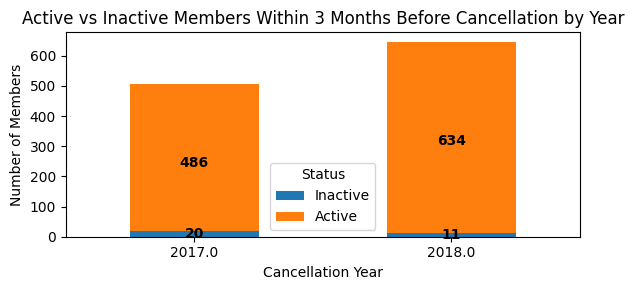

In [108]:
#Visualize
ax = summary_by_year.plot(kind='bar', stacked=True, figsize=(6,3))

plt.title('Active vs Inactive Members Within 3 Months Before Cancellation by Year')
plt.xlabel('Cancellation Year')
plt.ylabel('Number of Members')
plt.xticks(rotation=0)
plt.legend(title='Status')

for i, year in enumerate(summary_by_year.index):
    active_count = summary_by_year.loc[year, 'Active']
    inactive_count = summary_by_year.loc[year, 'Inactive']

    # Active
    ax.text(i, active_count / 2, str(active_count), ha='center', va='center', color='black', fontweight='bold')

    # Inactive
    ax.text(i, inactive_count / 2, str(inactive_count), ha='center', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

In [109]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=29327833f908e1955d6512593ce03a32ea558307797c1e7abdb46c95772fce6b
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [122]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

df = final.copy()

df['_orig_end_yyyymm'] = df['end_yyyymm']

# Convert start_yyyymm and end_yyyymm (NaN means not yet cancelled) to YYYYMM string and fill with 201812 as observation end
df['start_yyyymm'] = df['start_yyyymm'].astype(str).str.zfill(6)
df['end_yyyymm_for_calc'] = df['end_yyyymm'].fillna('201812').astype(str).str.zfill(6)

# Convert to datetime
df['start_date'] = pd.to_datetime(df['start_yyyymm'], format='%Y%m')
df['end_date'] = pd.to_datetime(df['end_yyyymm_for_calc'], format='%Y%m')

# Churn: Yes = 1, No = 0
df['churn'] = df['_orig_end_yyyymm'].notna().astype(int)

In [117]:
#Cohort Analysis (calculating average months by redeem bins)
bins = list(range(0, 101, 5)) + [np.inf]
labels = [f"{bins[i]}-{bins[i+1]}%" for i in range(len(bins)-1)]
labels[-2] = "95-100%"
labels[-1] = ">100%"

df['redeem_bin'] = pd.cut(df['Point Usage Percentage'],
                          bins=bins,
                          labels=labels,
                          right=False,
                          include_lowest=True)

df['cohort_year'] = df['start_date'].dt.year.astype(str)

In [118]:
# Calculate average months_enrolled for cohort_year × redeem_bin
cohort_summary = (
    df.groupby(['cohort_year','redeem_bin'])
    .agg(
        avg_months_enrolled=('months_enrolled','mean'),
        member_count=('Loyalty Number','count')
    )
    .reset_index()
)

print(cohort_summary.head())

  cohort_year redeem_bin  avg_months_enrolled  member_count
0        2012       0-5%            75.813559           413
1        2012      5-10%            75.202381            84
2        2012     10-15%            75.656716           201
3        2012     15-20%            75.627586           145
4        2012     20-25%            75.722892           166


/tmp/ipykernel_11279/2588058824.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['cohort_year','redeem_bin'])


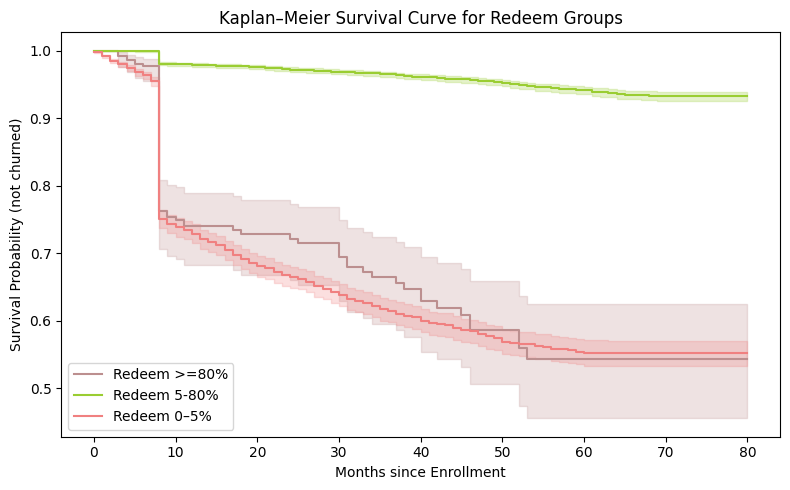

In [125]:
#Survival Analysis (Kaplan–Meier) — High vs Low redeem groups
duration = df['lifecycle_months']
event = df['churn']

kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()
kmf_0_5 = KaplanMeierFitter()

mask_high =(df['Point Usage Percentage'] >= 80)
mask_low = (df['Point Usage Percentage'] >= 5) & (df['Point Usage Percentage'] < 80)
# 0–5% redeem group
mask_0_5 = (df['Point Usage Percentage'] >= 0) & (df['Point Usage Percentage'] < 5)

# Fit
kmf_high.fit(durations=duration[mask_high], event_observed=event[mask_high], label='Redeem >=80%')
kmf_low.fit(durations=duration[mask_low], event_observed=event[mask_low], label='Redeem 5-80%')
kmf_0_5.fit(durations=duration[mask_0_5],event_observed=event[mask_0_5],label='Redeem 0–5%')

# Plot KM curves
plt.figure(figsize=(8,5))
ax = plt.subplot(111)
kmf_high.plot_survival_function(ax=ax, color='rosybrown')
kmf_low.plot_survival_function(ax=ax, color='yellowgreen')
kmf_0_5.plot_survival_function(ax=ax, color='lightcoral')
plt.title('Kaplan–Meier Survival Curve for Redeem Groups')
plt.xlabel('Months since Enrollment')
plt.ylabel('Survival Probability (not churned)')
plt.tight_layout()
plt.show()

In [123]:
# Log-rank test
results = logrank_test(
    duration[mask_high], duration[mask_low],
    event_observed_A=event[mask_high], event_observed_B=event[mask_low]
)
print("Log-rank test p-value:", results.p_value)
print(results.summary)

Log-rank test p-value: 2.646331784869133e-148
   test_statistic              p    -log2(p)
0      672.653064  2.646332e-148  490.241364
